# Step 7 -- 2D Diffusion

The 2D diffusion (heat) equation:

$$
\frac{\partial u}{\partial t}
= \nu \left(
  \frac{\partial^2 u}{\partial x^2}
+ \frac{\partial^2 u}{\partial y^2}
\right)
$$

**What you will learn:**

1. How diffusion smooths a 2D field
2. Validation against the analytical Gaussian solution
3. Energy dissipation in 2D
4. Differentiating through the diffusion coefficient $\nu$

## Physics

Diffusion spreads concentration from high to low regions. A 2D Gaussian initial condition remains Gaussian for all time, with a width that grows as $\sigma(t) = \sqrt{\sigma_0^2 + 2\nu t}$. The peak decays as $\sigma_0^2 / \sigma(t)^2$ so that total mass is conserved. This analytical solution provides an exact benchmark for the numerical solver.

## Grid layout and boundary conditions

In 2D, somax uses the **Arakawa C-grid** where different variables live at different positions within each cell:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

- **T-points** (cell centres): scalars ($u$, $p$, $\omega$)
- **U-points** (east/west faces): x-fluxes
- **V-points** (north/south faces): y-fluxes
- **X-points** (corners): vorticity (in some formulations)

The full array has shape `(Ny, Nx)` with a **1-cell ghost ring** on all sides:

```
 ┌───────────────────────────────────┐
 │  ghost  ghost  ghost  ghost  ghost│  ← row 0
 │  ghost  T(1,1) T(1,2) ···   ghost│  ← row 1
 │  ghost  T(2,1) T(2,2) ···   ghost│
 │   ⋮      ⋮      ⋮           ⋮    │
 │  ghost  T(n,1) T(n,2) ···   ghost│  ← row Ny-2
 │  ghost  ghost  ghost  ghost  ghost│  ← row Ny-1
 └───────────────────────────────────┘
        col 0  col 1  ···  col Nx-1
```

Interior cells are `[1:-1, 1:-1]`. Ghost cells are filled by boundary conditions before each RHS evaluation.

**Periodic BCs** (`enforce_periodic`) copy the last interior row/column to the opposite ghost row/column:

```
 field[0, :]  = field[-2, :]   (south ghost ← north interior)
 field[-1, :] = field[1, :]    (north ghost ← south interior)
 field[:, 0]  = field[:, -2]   (west ghost ← east interior)
 field[:, -1] = field[:, 1]    (east ghost ← west interior)
```

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import Diffusion2D, Diffusion2DState

## 1. Create the model

In [2]:
nu = 0.05
model = Diffusion2D.create(nx=64, ny=64, Lx=4.0, Ly=4.0, nu=nu)
print(model)
print(f"Grid: Nx={model.grid.Nx}, Ny={model.grid.Ny}")
print(f"Spacing: dx={model.grid.dx:.4f}, dy={model.grid.dy:.4f}")

Diffusion2D(
  params=Diffusion2DParams(nu=weak_f32[]),
  grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=4.0, Ly=4.0, dx=0.0625, dy=0.0625),
  diff=Difference2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=4.0, Ly=4.0, dx=0.0625, dy=0.0625)
  )
)
Grid: Nx=66, Ny=66
Spacing: dx=0.0625, dy=0.0625


## 2. Initial condition

A 2D Gaussian centred at $(2.0, 2.0)$:

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
y = jnp.arange(model.grid.Ny) * model.grid.dy
X, Y = jnp.meshgrid(x, y)

sigma0 = 0.3
mu_x, mu_y = 2.0, 2.0
u0 = jnp.exp(-0.5 * (((X - mu_x) / sigma0) ** 2 + ((Y - mu_y) / sigma0) ** 2))
state0 = Diffusion2DState(u=u0)

print(f"State shape: u={state0.u.shape}")
print(f"Peak value: {float(jnp.max(u0)):.4f}")

State shape: u=(66, 66)
Peak value: 1.0000


## 3. Run the simulation

In [4]:
dt = 0.002
t_final = 1.0
ts = jnp.arange(0.0, t_final, dt)

sol = model.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Solution shape: {sol.ys.u.shape}")

Solution shape: (500, 66, 66)


## 4. Visualize spreading

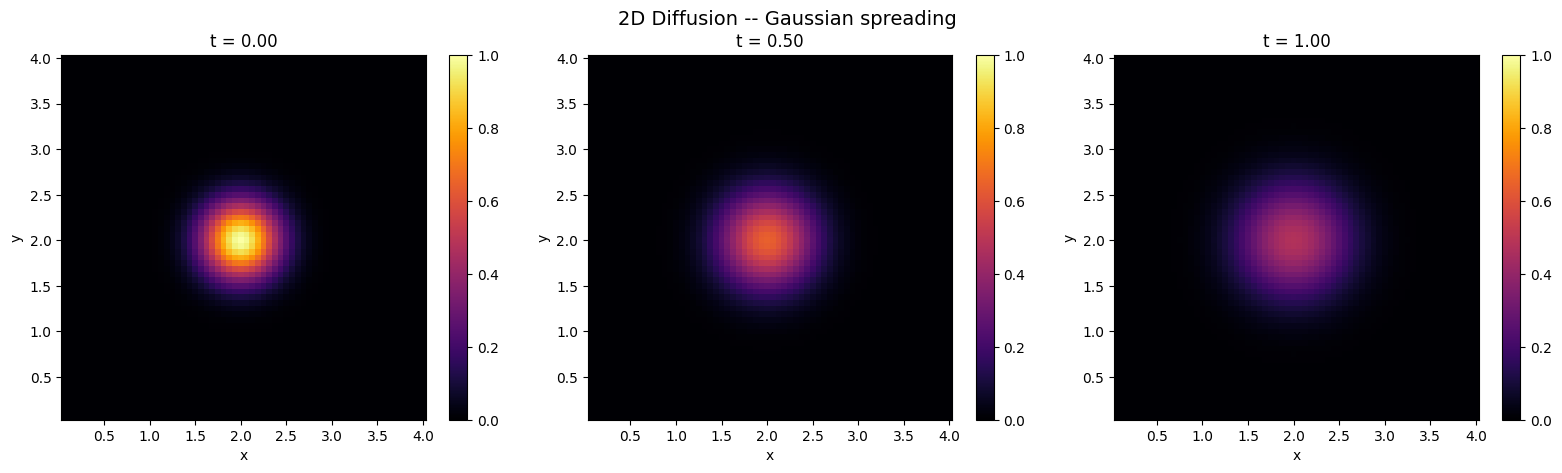

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

snapshots = [0, len(ts) // 2, -1]
for ax, idx in zip(axes, snapshots, strict=True):
    t_snap = float(ts[idx])
    field = sol.ys.u[idx]
    pcm = ax.pcolormesh(
        X[1:-1, 1:-1],
        Y[1:-1, 1:-1],
        field[1:-1, 1:-1],
        shading="auto",
        cmap="inferno",
        vmin=0.0,
        vmax=1.0,
    )
    plt.colorbar(pcm, ax=ax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"t = {t_snap:.2f}")
    ax.set_aspect("equal")

plt.suptitle("2D Diffusion -- Gaussian spreading", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Analytical comparison

The exact solution for a Gaussian initial condition under 2D diffusion is:

$$
u_{\text{exact}}(x, y, t)
= \frac{\sigma_0^2}{\sigma(t)^2}
  \exp\!\left[
    -\frac{(x - \mu_x)^2 + (y - \mu_y)^2}{2\,\sigma(t)^2}
  \right],
\qquad
\sigma(t) = \sqrt{\sigma_0^2 + 2\nu t}
$$

In [6]:
t_end = float(ts[-1])
sigma_t = jnp.sqrt(sigma0**2 + 2.0 * nu * t_end)
u_analytical = (sigma0**2 / sigma_t**2) * jnp.exp(
    -0.5 * (((X - mu_x) / sigma_t) ** 2 + ((Y - mu_y) / sigma_t) ** 2)
)
u_numerical = sol.ys.u[-1]

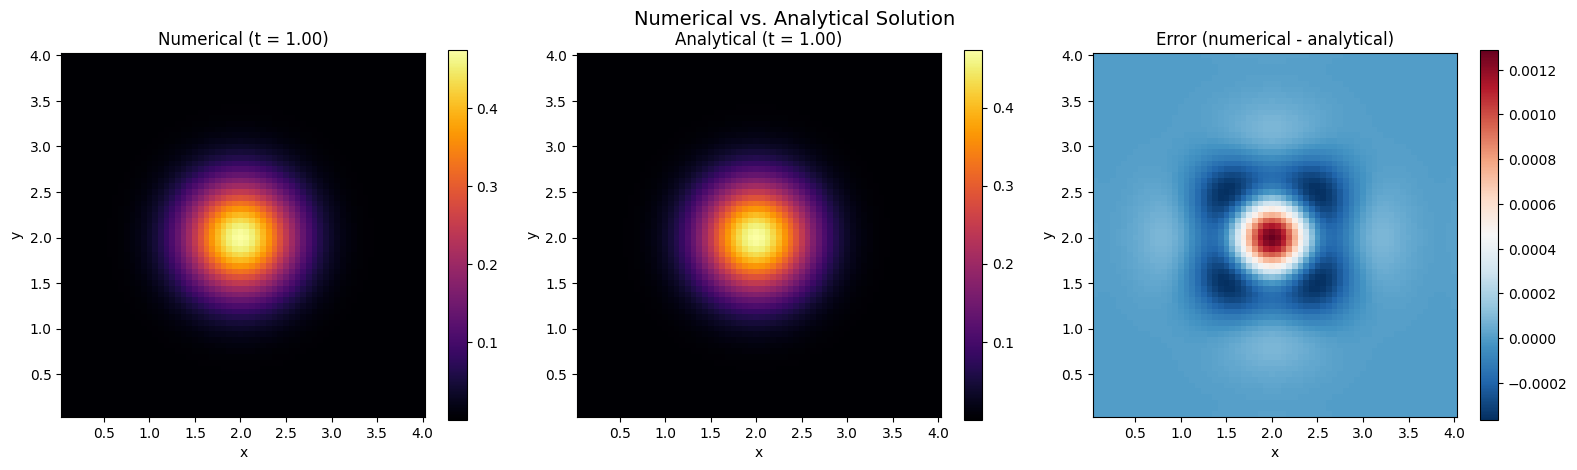

Max absolute error: 0.001290


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pcm0 = axes[0].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    u_numerical[1:-1, 1:-1],
    shading="auto",
    cmap="inferno",
)
plt.colorbar(pcm0, ax=axes[0])
axes[0].set_title(f"Numerical (t = {t_end:.2f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

pcm1 = axes[1].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    u_analytical[1:-1, 1:-1],
    shading="auto",
    cmap="inferno",
)
plt.colorbar(pcm1, ax=axes[1])
axes[1].set_title(f"Analytical (t = {t_end:.2f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

error = u_numerical - u_analytical
pcm2 = axes[2].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    error[1:-1, 1:-1],
    shading="auto",
    cmap="RdBu_r",
)
plt.colorbar(pcm2, ax=axes[2])
axes[2].set_title("Error (numerical - analytical)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

plt.suptitle("Numerical vs. Analytical Solution", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Max absolute error: {float(jnp.max(jnp.abs(error[1:-1, 1:-1]))):.6f}")

## 6. Energy decay

Diffusion dissipates energy. The total energy $E(t) = \tfrac{1}{2}\sum u^2\,dx\,dy$ should decrease monotonically.

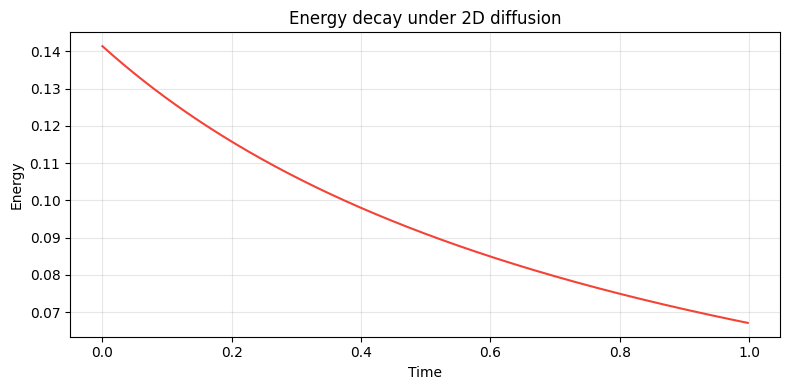

Energy: initial = 0.141372, final = 0.067127
Ratio: 0.4748


In [8]:
dx, dy = float(model.grid.dx), float(model.grid.dy)
energy = 0.5 * jnp.sum(sol.ys.u[:, 1:-1, 1:-1] ** 2, axis=(1, 2)) * dx * dy

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, energy, lw=1.5, color="#F44336")
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Energy decay under 2D diffusion")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Energy: initial = {float(energy[0]):.6f}, final = {float(energy[-1]):.6f}")
print(f"Ratio: {float(energy[-1] / energy[0]):.4f}")

## 7. Gradient through the diffusion coefficient

We can compute $\partial \mathcal{L} / \partial \nu$ to answer: "how does the total energy at final time change if we increase the diffusion coefficient?"

In [9]:
@eqx.filter_grad
def grad_nu(m):
    sol = m.integrate(state0, t0=0.0, t1=0.5, dt=0.002)
    return jnp.sum(sol.ys.u**2)


grads = grad_nu(model)

print("--- Gradient w.r.t. diffusion coefficient ---")
print(f"  dL/d(nu) = {grads.params.nu:.6f}")
print("  (negative => increasing nu decreases total energy, as expected)")

--- Gradient w.r.t. diffusion coefficient ---


  dL/d(nu) = -332.448364
  (negative => increasing nu decreases total energy, as expected)


## 8. Peak decay over time

The analytical peak decays as $\sigma_0^2 / (\sigma_0^2 + 2\nu t)$. We compare this prediction against the numerical peak.

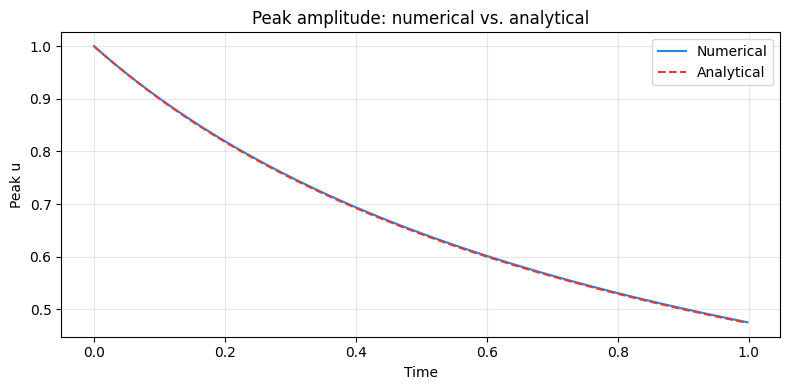

In [10]:
numerical_peak = jnp.max(sol.ys.u[:, 1:-1, 1:-1], axis=(1, 2))
analytical_peak = sigma0**2 / (sigma0**2 + 2.0 * nu * ts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, numerical_peak, lw=1.5, label="Numerical", color="#1E88E5")
ax.plot(ts, analytical_peak, lw=1.5, ls="--", label="Analytical", color="#E53935")
ax.set_xlabel("Time")
ax.set_ylabel("Peak u")
ax.set_title("Peak amplitude: numerical vs. analytical")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | API |
|---------|-----|
| Create model | `Diffusion2D.create(nx=64, ny=64, Lx=4.0, Ly=4.0, nu=0.05)` |
| State | `Diffusion2DState(u=u0)` |
| Analytical solution | $\sigma(t) = \sqrt{\sigma_0^2 + 2\nu t}$ |
| Energy dissipation | monotonic decay of $\sum u^2$ |
| Grad w.r.t. $\nu$ | `eqx.filter_grad(loss)(model)` |

**Next:** Step 8 combines nonlinear convection and diffusion into the 2D Burgers equation.